In [1]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

In [2]:
from src.paths import DATA_DIR
from src.Qlassifier.prediction import run_tf_idf

/home/ykip10/projects/Qlassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
subjects = ["chemistry", "specialist_mathematics"]
exams = ["2023", "2023_2"]

results = []
for subject, exam in zip(subjects, exams):
    subject_path = DATA_DIR / subject
    exam_path = subject_path / "past_exams" / f"{exam}.pdf"
    result = run_tf_idf(exam_path, subject, include_report=True)
    results.append(result)

/home/ykip10/projects/Qlassifier/src/preprocessor/loading.py:138: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(df["label"].str.contains(


## Evaluation

Since I am no expert in chemistry, I supplied GPT-5 with the necessary documents and asked it to hand-label the best topic classificaitons for us. Unfortunately, for whatever reason, gpt-5 could only reliably label MCQ questions and wasn't very helpful for short answer ones. But alas, even the mcq was of very low quality - by my calculations even worse than this rudimentary TF-IDF approach - as i detected with my limited chemistry knowledge. So, I will hand label on this occasion to the best of my ability, with the help of GPT-5 on individual questions, one at a time.

In [4]:
true_topic_mcq = [
    0, 2, 6, 5, 10, 9, 0, 4, 0, 4,
    3, 3, 6, 4, 0, 9, 1, 9, 6, 8,
    10 ,2, 6, 2, 5, 11, 12, 2, 9, 2,
]

true_topic_indices = true_topic_mcq + [
    6, 7, 7, 6, 6, 2, 2, 2, 2,   # Q1
    6, 10, 10, 10, 6, 10, 6, 10, # Q2
    0, 0, 0, 0, 0, 6,            # Q3
    7, 6, 7, 7, 7,               # Q4
    0, 4, 4, 3,                  # Q5
    2, 2, 2, 2, 2,               # Q6 
    9, 9, 9, 9, 9,               # Q7
    3, 11, 11, 1, 1, 12, 11, 12, # Q8
    5, 5                         # Q9
]

chem_res = results[0]
chem_res.correct_topics=true_topic_indices
chem_df = chem_res.pred_df

In [5]:
round(chem_res.summary(by="topic"), 2)

,Carbon-based fuels,Measuring changes in chemical reactions,Primary galvanic cells and fuel cells as sources of energy,Rates of chemical reactions,Extent of chemical reactions,Production of chemicals using electrolysis,"Structure, nomenclature and properties of organic compounds",Reactions of organic compounds,Laboratory analysis of organic compounds,Instrumental analysis of organic compounds,Medicinal chemistry,Investigation design,Scientific evidence,Science communication
Predicted Topic Counts,13.00,7.00,8.00,2.00,11.00,18.00,4.00,6.00,0.00,8.00,4.00,1.00,0.00,0.0
Predicted Topic Proportions,0.16,0.09,0.10,0.02,0.13,0.22,0.05,0.07,0.00,0.10,0.05,0.01,0.00,0.0
Topic Count,10.00,3.00,14.00,4.00,5.00,4.00,12.00,6.00,1.00,9.00,7.00,4.00,3.00,0.0
Topic Proportion,0.12,0.04,0.17,0.05,0.06,0.05,0.15,0.07,0.01,0.11,0.09,0.05,0.04,0.0
Precision,0.54,0.43,1.00,0.50,0.45,0.22,1.00,0.50,0.00,1.00,0.75,1.00,0.00,0.0
Recall,0.70,1.00,0.57,0.25,1.00,1.00,0.33,0.50,0.00,0.89,0.43,0.25,0.00,0.0
F1-Score,0.61,0.60,0.73,0.33,0.62,0.36,0.50,0.50,0.00,0.94,0.55,0.40,0.00,0.0


In [6]:
round(chem_res.summary(by="overall"), 2)

Accuracy              0.57
Top 3 Accuracy        0.71
Macro-Precision       0.53
Macro-Recall          0.49
Macro-F1-Score        0.44
Weighted-Precision    0.72
Weighted-Recall       0.57
Weighted-F1-Score     0.57
dtype: float64

In [7]:
incorrect_chem = chem_df[chem_df["pred_topic_idx"] != chem_df["true_topic_idx"]]
correct_chem = chem_df[chem_df["pred_topic_idx"] == chem_df["true_topic_idx"]]
incorrect_chem.head(5)

,label,text,comments,total_marks,pred_topic,pred_topic_idx,confidence,true_topic_idx,true_topic
6,Question 7,Consider the following statements about fossil...,Biofuel production potentially does damage the...,1,Measuring changes in chemical reactions,1,0.148594,0,Carbon-based fuels
10,Question 11,student conducted an experiment to determine t...,Reaction rate is the change in the quantity of...,1,Extent of chemical reactions,4,0.247114,3,Rates of chemical reactions
14,Question 15,Consider two types of drone: petrol-powered an...,Petrol-powered drones convert chemical energy ...,1,Measuring changes in chemical reactions,1,0.256629,0,Carbon-based fuels
17,Question 18,The graph below shows the HPLC calibration cur...,According to the calibration curve for diluted...,1,Extent of chemical reactions,4,0.134406,9,Instrumental analysis of organic compounds
19,Question 20,Which one of the following is always correct w...,There was no correct or best answer to this qu...,1,Production of chemicals using electrolysis,5,0.111760,8,Laboratory analysis of organic compounds


Let's check how good our confidence metric is.

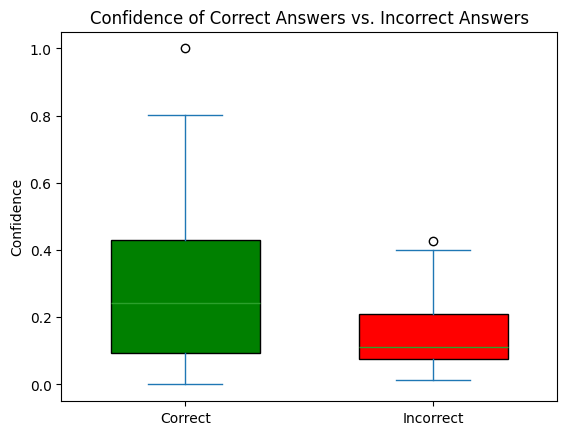

In [8]:
chem_res.plot_conf()

It doesn't look like confidence is really the best metric of whether or not a prediction is correct or not... although it does capture some signal

We move on to a mathematics subject, in which we expect our 'model' to perform FAR worse, since we don't have LaTeX data and plenty of the context is in the LaTeX for math exams, especially relative to chemistry ones. This one I hand label reliably.

In [9]:
mcq_labels = [
    0, 1, 1, 2, 2, 4, 4, 4, 7, 3, 
    3, 5, 5, 6, 6, 8, 6, 7, 9, 11,
]

ground_truth = mcq_labels + [
    1, 3, 3, 3, 7, 8, 3, 3,            # Q1
    2, 2, 2, 2, 2, 2, 2, 2,            # Q2
    3, 3, 3, 3, 3, 3,                  # Q3
    4, 4, 4, 4, 4, 4, 1, 4,            # Q4
    6, 6, 7, 7, 7, 7,                  # Q5
    11, 11, 11, 12, 12, 12, 12, 12, 10 # Q6  

]

math_res = results[1]
math_res.correct_topics = ground_truth
math_res.pred_df.head()

,label,text,comments,total_marks,pred_topic,pred_topic_idx,confidence,true_topic_idx,true_topic
0,Question 1,Consider the following statement. ‘If my footb...,,1,Discrete mathematics: Logic and proof,0,0.312597,0,Discrete mathematics: Logic and proof
1,Question 2,The graph of ax bx has asymptotes given by and...,,1,"Data analysis, probability and statistics: Dis...",10,0.025168,1,"Functions, relations and graphs"
2,Question 3,"In the interval π π the graph of sec( ), where...",,1,"Data analysis, probability and statistics: Con...",11,0.373191,1,"Functions, relations and graphs"
3,Question 4,"If − 1) ai where is non-zero real constant, t...",,1,"Data analysis, probability and statistics: Dis...",9,1.000000,2,"Algebra, number and structure: Complex numbers"
4,Question 5,Let be complex number where Re( and Im( 0. Giv...,,1,"Algebra, number and structure: Complex numbers",2,0.251177,2,"Algebra, number and structure: Complex numbers"


In [10]:
round(math_res.summary(by="topic"), 2)

,Discrete mathematics: Logic and proof,"Functions, relations and graphs","Algebra, number and structure: Complex numbers",Calculus: Differential calculus and integral calculus,Calculus: Differential equations,Calculus: Kinematics: rectilinear motion,Space and measurement: Vectors,Space and measurement: Vector and Cartesian equations,Space and measurement: Vector calculus,"Data analysis, probability and statistics: Distribution of linear combinations of random variables","Data analysis, probability and statistics: Distribution of the sample mean","Data analysis, probability and statistics: Confidence intervals for the population mean","Data analysis, probability and statistics: Hypothesis testing for a population mean with a sample drawn from a normal distribution of known variance, or for a large sample"
Predicted Topic Counts,1.00,0.00,5.00,7.00,2.00,1.00,6.00,6.00,2.00,2.00,13.00,19.00,1.00
Predicted Topic Proportions,0.02,0.00,0.08,0.11,0.03,0.02,0.09,0.09,0.03,0.03,0.20,0.29,0.02
Topic Count,1.00,4.00,10.00,13.00,10.00,2.00,5.00,7.00,2.00,1.00,1.00,4.00,5.00
Topic Proportion,0.02,0.06,0.15,0.20,0.15,0.03,0.08,0.11,0.03,0.02,0.02,0.06,0.08
Precision,1.00,0.00,1.00,0.86,1.00,1.00,0.67,0.67,0.00,0.00,0.08,0.16,1.00
Recall,1.00,0.00,0.50,0.46,0.20,0.50,0.80,0.57,0.00,0.00,1.00,0.75,0.20
F1-Score,1.00,0.00,0.67,0.60,0.33,0.67,0.73,0.62,0.00,0.00,0.14,0.26,0.33


In [11]:
round(math_res.summary(by="overall"), 2)

Accuracy              0.43
Top 3 Accuracy        0.63
Macro-Precision       0.57
Macro-Recall          0.46
Macro-F1-Score        0.41
Weighted-Precision    0.74
Weighted-Recall       0.43
Weighted-F1-Score     0.48
dtype: float64

The model clearly over-predicts probability topics with an astoundingly low precision of 0.06. This is simply because they have the most text and the least LaTeX. 

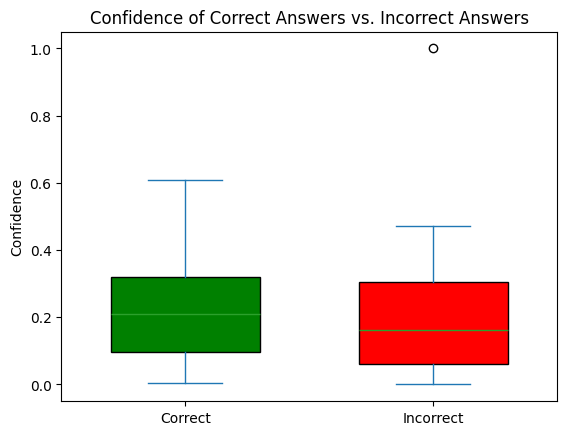

In [12]:
math_res.plot_conf()

We can see that confidence means even less in this case. 

As expected! These results both serve as our base-line and possible avenues for exploration, seeing as some signal is still captured, and there is decent performance on Chemistry, because LaTeX is far and few in between compared to math exams. 

In [13]:
import pickle

Path("saved_results").mkdir(exist_ok=True)

with open("saved_results/tfidf_chem_res.pkl", "wb") as f:
    pickle.dump(chem_res, f)
with open("saved_results/tfidf_math_res.pkl", "wb") as f:
    pickle.dump(math_res, f)